In [4]:
import argparse
import anndata as ad
import pandas as pd

In [28]:
input = "/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture/output/model.posterior.count.tsv.gz"
h5ad = "/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture/ficture_factor.h5ad"
zarr = "/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture_factors/sdata.zarr"
table_name="ficture_factor"

In [29]:
df = pd.read_csv(input, sep="\t", index_col=0).T
df.shape

(21, 499)

In [30]:
df

gene,Eno2,Col4a3,Mfge8,Itga3,Tnfrsf1a,Prox1,Atad2,Tacc3,Pf4,Hsp90aa1,...,Vcan,Sox17,Lamp5,Fga,Ang4,Fgg,Ereg,Ang2,Apcs,Gzma
0,11853.41,208.92,7964.76,2872.87,1213.04,2165.26,517.21,305.26,154.59,7769.51,...,1165.36,302.57,8127.76,200.25,110.04,105.31,75.91,166.49,173.12,297.15
1,21082.82,358.14,108657.09,3986.16,6081.83,3844.96,1003.68,522.37,316.17,15721.52,...,3560.52,628.11,9966.08,542.91,273.88,166.86,174.24,396.45,275.59,1057.33
2,7583.25,117.64,7767.82,1465.79,994.00,1377.65,318.62,176.06,175.13,5220.64,...,823.55,182.10,4219.60,123.03,66.91,55.95,44.31,89.45,89.55,227.02
3,17627.00,248.67,19129.14,3817.35,2038.94,4624.68,699.38,426.13,197.98,11741.47,...,1915.81,369.86,8186.42,248.42,153.36,120.83,92.98,207.46,204.01,431.88
4,9311.58,490.38,13270.83,3599.82,2845.88,1807.01,571.53,352.91,211.97,6966.85,...,1423.67,1593.48,5544.44,267.72,139.94,137.67,110.83,198.42,302.44,564.70
5,9594.71,323.73,10204.76,3046.32,1644.24,1880.17,469.01,255.94,118.49,11617.14,...,1315.88,289.56,6350.04,913.48,123.33,101.43,101.56,139.31,128.56,415.63
6,3655.31,55.30,3159.95,721.36,339.25,667.23,148.59,84.23,39.98,2464.13,...,362.79,81.82,2329.72,55.04,31.03,26.67,19.21,43.64,42.76,88.29
7,6003.64,140.35,5659.62,1093.28,1589.06,1210.38,467.62,199.91,75.72,4128.92,...,643.13,175.99,3772.56,134.75,57.36,56.28,40.36,95.63,115.11,153.75
8,96887.02,1061.30,22544.37,20416.51,2079.64,17705.11,2568.54,2022.07,883.65,57352.53,...,5671.28,1289.38,55061.31,934.30,716.70,588.94,397.45,876.28,1008.00,1301.82
9,34482.47,353.34,7921.29,7629.68,665.97,4252.37,838.27,572.61,263.12,21517.92,...,3087.72,504.98,14094.70,291.92,483.06,189.48,138.62,323.06,293.18,438.31


In [31]:
adata = ad.AnnData(X=df.values.astype("float32"))
adata.obs_names = [f"factor_{c}" for c in df.index]
adata.var_names = df.columns
adata

AnnData object with n_obs × n_vars = 21 × 499

In [32]:
adata.obs_names

Index(['factor_0', 'factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5',
       'factor_6', 'factor_7', 'factor_8', 'factor_9', 'factor_10',
       'factor_11', 'factor_12', 'factor_13', 'factor_14', 'factor_15',
       'factor_16', 'factor_17', 'factor_18', 'factor_19', 'factor_20'],
      dtype='object')

In [33]:
adata.var

""
gene
Eno2
Col4a3
Mfge8
Itga3
Tnfrsf1a
...
Fgg
Ereg
Ang2


In [34]:
import spatialdata as sd
sd.SpatialData(tables={table_name: adata}).write(zarr)

INFO     The Zarr backing store has been changed from None the new file path:                                      
         /dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture_factors/sdata.za
         rr                                                                                                        


In [ ]:
sd

# Boundaries

Input. The pixel decode file (decode.pixel.sorted.tsv.gz), where every tiny pixel of tissue carries its winning factor K1. Plus the header values offx, offy, scale so you can turn the stored integer coordinates back into real micrometers.
Processing.

1. Read just the columns you need: X, Y, K1. Convert X,Y from stored integers back to µm (/scale + offset).
2. Lay a grid over the tissue with 5 µm squares. Compute which grid cell (row, col) each pixel falls into.
3. Vote per cell: within each 5 µm square, count how many pixels belong to each factor and keep the winner (majority factor). This collapses millions of pixels into one factor label per square.
4. Build a label image: a 2D array where each square holds its winning factor (background stays 0).
5. Trace outlines: rasterio.features.shapes walks the label image and draws a polygon around every connected patch of same-factor squares. The affine tr stamps those polygons back into real µm coordinates.

Output. A GeoDataFrame (gdf): one row per connected patch = a pseudo-cell, with its factor and its area_um2. From here you sum or count areas per factor, or drop it into sdata.shapes as boundaries.
In one line: pixels labeled by factor → snapped to a 5 µm grid by majority vote → outlined into polygons whose areas give factor/pseudo-cell sizes.

# TODO  
- check cell type to factor match! possibly re-run ficture with adjusted input matrix.
- check images - can the falsely huge interconnected cells be reduced by using connectivity=4 instead of connectivity=8?
- implement ficture_segments_to_sdata: use the logic set up here
- to ficture_factors_to_sdata: add one boundary per factor instead by using gdf.dissolve(by="factor")!



In [ ]:
%pip install rasterio

In [90]:
pixels = "/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture/output/decode.pixel.sorted.tsv.gz"

In [95]:
%%time

import numpy as np, pandas as pd, rasterio, gzip
import rasterio.features as rf
from shapely.geometry import shape
import geopandas as gpd
from skimage.morphology import remove_small_objects, remove_small_holes

res = 1
min_um2 = 5

# --- read header: offsets, scale, column names ---
meta = {}
with gzip.open(pixels, "rt") as f:
    for line in f:
        if line.startswith("##"):
            meta.update(kv.split("=") for kv in line[2:].strip().split(";"))
        elif line.startswith("#"):
            cols = line[1:].strip().split("\t")
            break
offx, offy, scale = float(meta["OFFSET_X"]), float(meta["OFFSET_Y"]), float(meta["SCALE"])

# --- pixels -> um -> grid cell ---
df = pd.read_csv(pixels, sep="\t", comment="#", names=cols, usecols=["X","Y","K1"])
df.X = df.X / scale + offx
df.Y = df.Y / scale + offy
df["col"] = ((df.X - offx) / res).astype(int)
df["row"] = ((df.Y - offy) / res).astype(int)

# --- majority factor per grid cell ---
c = df.groupby(["row","col","K1"]).size().reset_index(name="n")
win = c.loc[c.groupby(["row","col"])["n"].idxmax()]
lab = np.zeros((win.row.max()+1, win.col.max()+1), np.int32)   # 0 = background
lab[win.row, win.col] = win.K1 + 1                             # shift so 0 stays empty

# --- clean: drop tiny blobs, fill tiny holes (per factor) ---
mp = int(min_um2 / res**2)
clean = np.zeros_like(lab)
for f in np.unique(lab[lab > 0]):
    m = remove_small_objects(lab == f, min_size=mp)
    m = remove_small_holes(m, area_threshold=mp)
    clean[m & (clean == 0)] = f
lab = clean

# --- polygonize -> pseudo-cells ---
tr = rasterio.Affine(res, 0, offx, 0, res, offy)
recs = [{"factor": int(v)-1, "geometry": shape(g)}
        for g, v in rf.shapes(lab, mask=lab>0, transform=tr, connectivity=8)]
gdf = gpd.GeoDataFrame(recs)
gdf["area_um2"] = gdf.geometry.area

CPU times: user 3min 40s, sys: 35.3 s, total: 4min 15s
Wall time: 4min 16s


In [140]:
gdf

,factor,geometry,area_um2,ficture_cell_type
0,13,"POLYGON ((9560.43 5583.76, 9560.43 5584.76, 95...",9.0,OPCs
1,12,"POLYGON ((9536.43 5583.76, 9536.43 5584.76, 95...",65.0,OECs
2,4,"POLYGON ((9598.43 5583.76, 9598.43 5584.76, 95...",53.0,Immune-Other
3,16,"POLYGON ((9575.43 5590.76, 9575.43 5592.76, 95...",6.0,SMCs
4,1,"POLYGON ((9553.43 5585.76, 9553.43 5586.76, 95...",30.0,BAMs
...,...,...,...,...
163779,11,"POLYGON ((6293.43 11666.76, 6293.43 11668.76, ...",57.0,Neurons-Other
163780,12,"POLYGON ((6301.43 11666.76, 6301.43 11667.76, ...",52.0,OECs
163781,1,"POLYGON ((6295.43 11641.76, 6295.43 11643.76, ...",463.0,BAMs
163782,11,"POLYGON ((6456.43 11617.76, 6456.43 11619.76, ...",2548.0,Neurons-Other


In [136]:
# add cell type annotation
import sys
from pathlib import Path
sys.path.append(str(Path("..") / "cellseg_benchmark"))
import _constants

f2ct = _constants.factor_to_celltype
colors = _constants.cell_type_colors
true = _constants.true_cluster
resolve = lambda ct: (true.get(ct) or [ct])[0]

# factor -> cell type -> color-matching name
gdf["ficture_cell_type"] = gdf.factor.astype(str).map(f2ct).map(resolve)
adata.obs["ficture_cell_type"] = adata.obs_names.str.removeprefix("factor_").map(f2ct).map(resolve)

missing = set(gdf.ficture_cell_type[gdf.ficture_cell_type.map(colors).isna()])
assert not missing, f"cell types missing from colors: {missing}"

order = list(colors)        # cell_type_colors key order
gdf["ficture_cell_type"] = pd.Categorical(gdf.ficture_cell_type, categories=order, ordered=True)
gdf["ficture_cell_type"] = gdf.ficture_cell_type.cat.remove_unused_categories()
adata.obs["ficture_cell_type"] = pd.Categorical(adata.obs.ficture_cell_type, categories=order, ordered=True)
adata.obs["ficture_cell_type"] = adata.obs.ficture_cell_type.cat.remove_unused_categories()

In [137]:
adata.obs["ficture_cell_type"].value_counts(dropna=False)

ficture_cell_type
Astrocytes                  2
VLMCs                       2
Neurons-Dopa                2
ECs                         1
Pericytes                   1
SMCs                        1
Oligodendrocytes            1
OPCs                        1
Microglia                   1
Ependymal                   1
BAMs                        1
Immune-Other                1
Neurons-Glut                1
Neurons-Gaba                1
Neurons-Glyc-Gaba           1
Neurons-Granule-Immature    1
Neurons-Other               1
OECs                        1
Name: count, dtype: int64

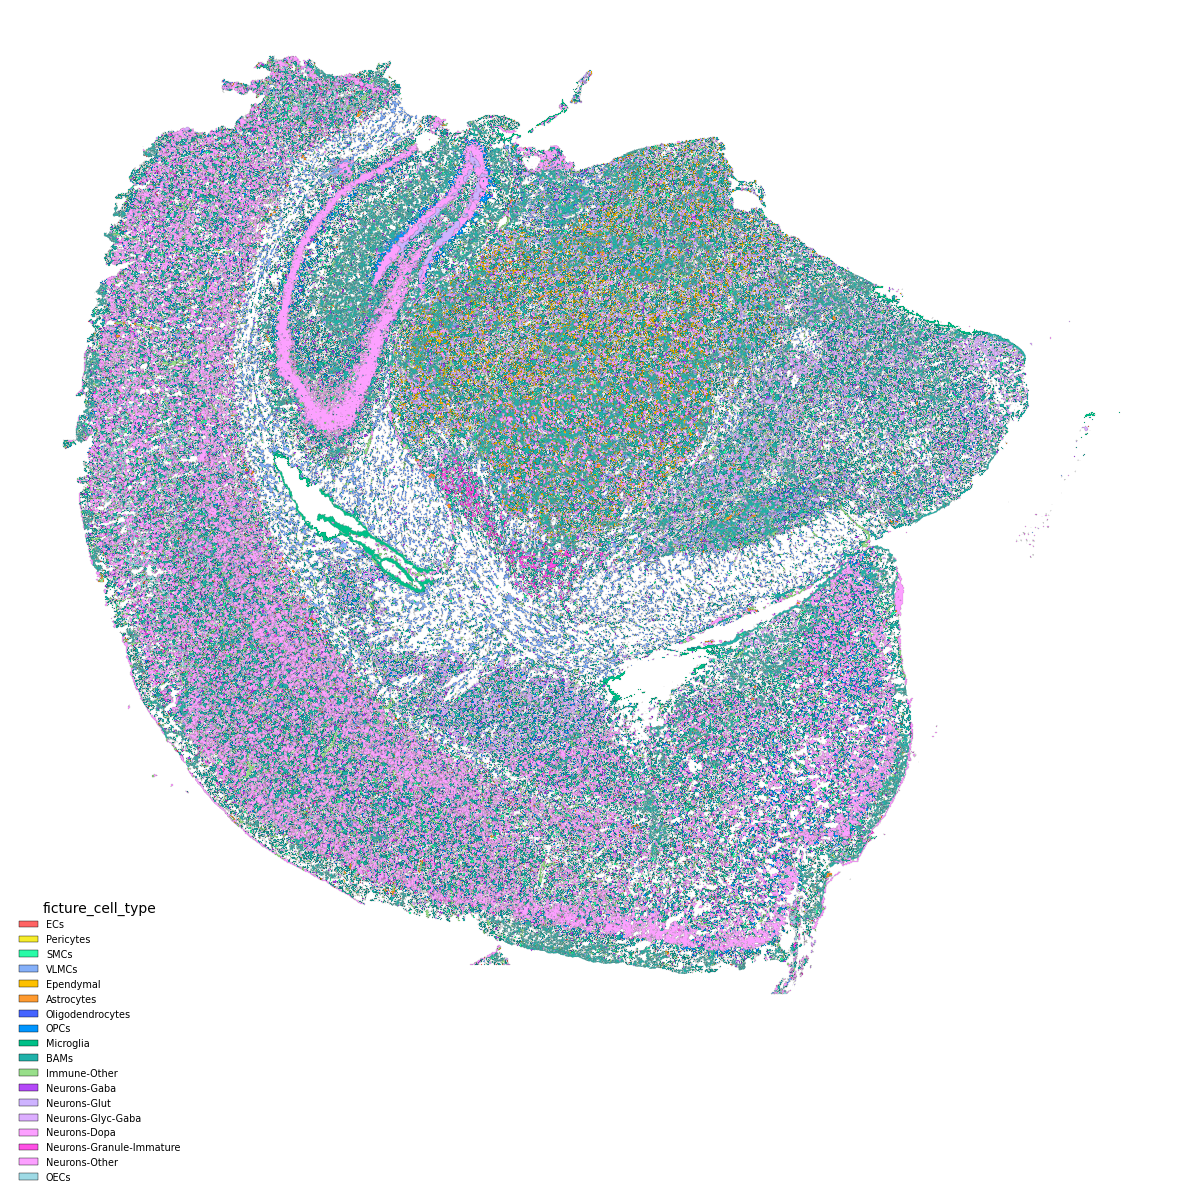

CPU times: user 1min 28s, sys: 1.99 s, total: 1min 30s
Wall time: 1min 30s


In [139]:
%%time
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

c = gdf.ficture_cell_type.map(colors)
fig, ax = plt.subplots(figsize=(15, 15))
gdf.plot(color=c, ax=ax, linewidth=0.05, edgecolor="black")

present = gdf.ficture_cell_type.cat.categories
handles = [Patch(facecolor=colors[t], edgecolor="k", linewidth=0.3, label=t)
           for t in present]
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(0, 0),
          fontsize=7, frameon=False, title="ficture_cell_type")

ax.set_aspect("equal")
ax.axis("off")
pp="/dss/dssfs03/pn52re/pn52re-dss-0001/cellseg-benchmark/samples/foxf2_s7_r1/results/Ficture/TESTING/ficture_boundaries8.png"
plt.savefig(pp, dpi=1200, bbox_inches="tight")
plt.show()